## Project 3: Unsupervised Learning (Customer Segmentation)

#### Goal: Use distance-based algorithms to discover hidden mathematical groupings in unlabeled retail data.

#### Key Requirements:

- Apply Principal Component Analysis (PCA) to reduce 20+ columns of data into 2 or 3 dimensions.

- Use the "Elbow Method" and "Silhouette Score" to mathematically prove the optimal number of K-Means clusters.

- Translate the resulting clusters into actionable business "Personas."

#### Key Skills: Dimensionality reduction (PCA), K-Means clustering, distance metrics, business intelligence translation.

In [3]:
# Load necessary library
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [4]:
# Load and read behavioural dataset
data = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')
data.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
# Drop non-numeric identifiers
features_data = data.select_dtypes(include=['float64', 'int64']).copy()

In [6]:
# Fit and transform using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features_data)

In [7]:
scaled_data = pd.DataFrame(scaled_data, columns=features_data.columns)
print("Standardized shape:", scaled_data.shape)

Standardized shape: (1200, 4)


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
pca_data = pca.fit_transform(scaled_data)
print(f"Original features: {scaled_data.shape[1]}")
print(f"Reduced PCA features: {pca_data.shape[1]}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

Original features: 4
Reduced PCA features: 3
Total Explained Variance: 98.46%


In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_data, kmeans.labels_))

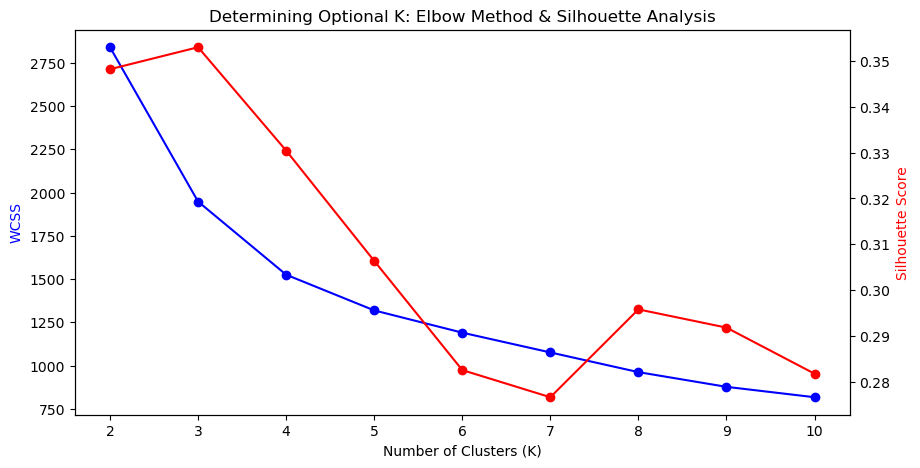

In [13]:
# Plotting elbow and Silhouette curves
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, wcss, 'bo-', label='WCSS (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'ro-', label = 'Silhouette Score')
ax2.set_ylabel('Silhouette Score', color = 'r')

plt.title('Determining Optional K: Elbow Method & Silhouette Analysis')
plt.show()

In [14]:
# Fit final model using chosen optimal k

optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = final_kmeans.fit_predict(pca_data)

In [15]:
# Profile clusters using original features
cluster_profile = data.groupby('Cluster')[features_data.columns].mean().round(2)
print("=== Cluster Means (Original Scale) ===")
print(cluster_profile)

=== Cluster Means (Original Scale) ===
         Quantity  UnitPrice  ItemsInCart  TotalPrice
Cluster                                              
0            1.76     169.02         3.96      291.58
1            4.19     536.69         7.03     2232.77
2            4.16     185.74         7.23      763.07
3            1.85     499.22         3.97      900.49


In [16]:
# Mapping numerical clusters to strategic personas
persona_map = {
    0: 'Affluent Conservatives',
    1: 'High-Value Trendsetters',
    2: 'Budget-Conscious Explorers',
    3: 'Conservative Minimizers'
}

data['Persona'] = data['Cluster'].map(persona_map)

print("\n=== Market Segment Distribution ===")
print(data['Persona'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))


=== Market Segment Distribution ===
Persona
Conservative Minimizers       27.8%
High-Value Trendsetters       24.9%
Affluent Conservatives        24.1%
Budget-Conscious Explorers    23.2%
Name: proportion, dtype: object
